# Bird's Eye View LiDAR Visualization by Cluster
This notebook visualizes the top view (Bird's Eye View) of a generated LiDAR PCD file, separating the environment/background from the actual objects (cars, pedestrians, etc.), and coloring the objects by their semantic cluster (`actor_id`).

In [5]:
import os
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

PCD_FILE = "../data/raw/lidar_with_intensity_and_clusters/frame_00006.pcd"

if not os.path.exists(PCD_FILE):
    print(f"Error: File {PCD_FILE} not found.")
else:
    # Read point cloud (double precision expected from MATLAB) using Tensor API
    t_pcd = o3d.t.io.read_point_cloud(PCD_FILE)
    
    # Extract points and actor_ids directly from the tensor dictionary
    points = t_pcd.point.positions.numpy()
    actor_ids = t_pcd.point.actor_id.numpy().flatten()
    
    # Filter out NaN points (no-returns)
    valid_mask = np.isfinite(points).all(axis=1)
    points = points[valid_mask]
    actor_ids = actor_ids[valid_mask]
    
    # In MATLAB drivingScenario, background/unlabeled points often get an ID of 4294967295 (uint32 max)
    # We will separate the background from the actual objects
    background_mask = actor_ids >= 1e6
    object_mask = actor_ids < 1e6
    
    bg_points = points[background_mask]
    obj_points = points[object_mask]
    obj_ids = actor_ids[object_mask]
    
    # Map the unique object IDs to 0, 1, 2... so the categorical colormap works perfectly
    unique_obj_ids = np.unique(obj_ids)
    id_map = {val: i for i, val in enumerate(unique_obj_ids)}
    mapped_obj_ids = np.array([id_map[val] for val in obj_ids])
    
    print(f"Loaded {len(bg_points)} background points.")
    print(f"Loaded {len(obj_points)} object points.")
    print(f"Unique Object Actor IDs: {unique_obj_ids}")


Loaded 10022 background points.
Loaded 42340 object points.
Unique Object Actor IDs: [1.0000e+00 2.0000e+00 3.0000e+00 4.0000e+00 5.0000e+00 1.0001e+04
 1.0002e+04 1.0003e+04 1.0004e+04 1.0005e+04 2.0001e+04 2.0002e+04
 2.0003e+04 2.0004e+04]


## Visualization
Plotting the X-Y plane using matplotlib. We plot the background in faint grey and the objects using distinct categorical colors.

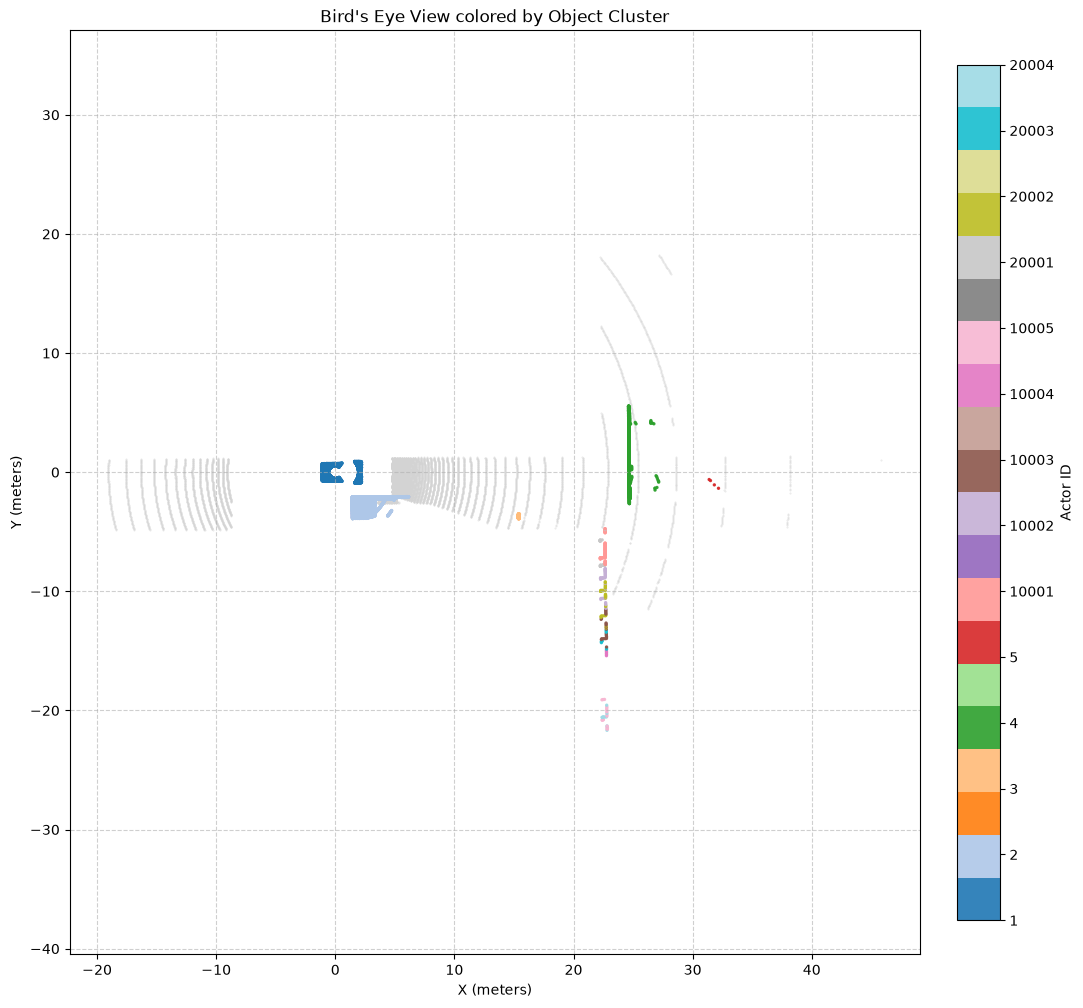

In [6]:
# Plotting Bird's Eye View
plt.figure(figsize=(12, 12))

# 1. Plot Background in faint grey
plt.scatter(bg_points[:, 0], bg_points[:, 1], s=0.2, c='lightgrey', alpha=0.5, label='Background')

# 2. Plot Objects with distinct colors
# We use 'tab20' which gives up to 20 distinct categorical colors
if len(obj_points) > 0:
    scatter = plt.scatter(obj_points[:, 0], obj_points[:, 1], s=2.0, c=mapped_obj_ids, cmap='tab20', alpha=0.9)
    
    # Add a custom legend or colorbar for the objects
    cbar = plt.colorbar(scatter, label='Actor ID', fraction=0.046, pad=0.04)
    # Relabel the ticks to the original Actor IDs
    ticks = np.arange(len(unique_obj_ids))
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(int(val)) for val in unique_obj_ids])

plt.title("Bird's Eye View colored by Object Cluster")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
